In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# 1. Load Dataset
# ----------------------------
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.23MB/s]


In [2]:

# ----------------------------
# 2. Add Noise Function
# ----------------------------
def add_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * torch.randn_like(images)
    noisy = torch.clamp(noisy, 0., 1.)  # keep values in [0,1]
    return noisy


In [8]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder (wider + deeper)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),   # (28x28)
            nn.ReLU(),
            nn.MaxPool2d(2),                  # -> (14x14)

            nn.Conv2d(32, 64, 3, padding=1),  # (14x14)
            nn.ReLU(),
            nn.MaxPool2d(2),                  # -> (7x7)

            nn.Conv2d(64, 64, 3, padding=1),  # deeper representation
            nn.ReLU()
        )

        # Decoder (mirror)
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='nearest'),  # 7 -> 14
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='nearest'),  # 14 -> 28
            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = DenoisingAutoencoder().to(device)

In [9]:

# ----------------------------
# 4. Loss & Optimizer
# ----------------------------
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ----------------------------
# 5. Training Loop
# ----------------------------
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)
        noisy_images = add_noise(images).to(device)

        outputs = model(noisy_images)
        loss = criterion(outputs, images)  # compare with CLEAN images

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/5], Loss: 0.1538
Epoch [2/5], Loss: 0.1059
Epoch [3/5], Loss: 0.1015
Epoch [4/5], Loss: 0.0995
Epoch [5/5], Loss: 0.0980


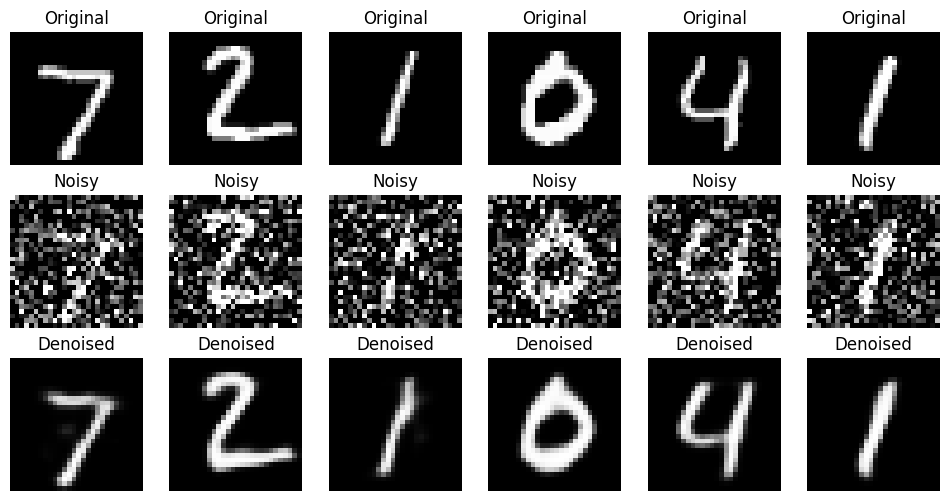

In [10]:

# ----------------------------
# 6. Visualization
# ----------------------------
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    noisy_images = add_noise(images)
    outputs = model(noisy_images)

images = images.cpu()
noisy_images = noisy_images.cpu()
outputs = outputs.cpu()

# Plot: Original vs Noisy vs Reconstructed
n = 6
plt.figure(figsize=(12,6))

for i in range(n):
    # Original
    plt.subplot(3, n, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    plt.subplot(3, n, i+1+n)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Reconstructed
    plt.subplot(3, n, i+1+2*n)
    plt.imshow(outputs[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.show()

**Discussion**

Looks good! The denoising autoencoder did a pretty good job at denoising the images. Though it does not capture the original thickness/thinness of the numbers as seen with 4 and the 1 on the right side which were made slightly thicker. But at least the images are recognizable.

# Making the Deep AutoEncoder

more Conv2D layers per blocks! Channel depth increased to 128 last time we had 64 channels.

In [11]:
class DeepDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DeepDenoisingAutoencoder, self).__init__()

        # ----------------------------
        # Encoder (DEEP)
        # ----------------------------
        self.encoder = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 -> 14

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 14 -> 7

            # Bottleneck
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU()
        )

        # ----------------------------
        # Decoder (DEEP + symmetric)
        # ----------------------------
        self.decoder = nn.Sequential(
            # Bottleneck decode
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),

            # Upsample 1
            nn.Upsample(scale_factor=2, mode='nearest'),  # 7 -> 14
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),

            # Upsample 2
            nn.Upsample(scale_factor=2, mode='nearest'),  # 14 -> 28
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


model = DeepDenoisingAutoencoder().to(device)

In [12]:

# ----------------------------
# 4. Loss & Optimizer
# ----------------------------
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ----------------------------
# 5. Training Loop
# ----------------------------
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)
        noisy_images = add_noise(images).to(device)

        outputs = model(noisy_images)
        loss = criterion(outputs, images)  # compare with CLEAN images

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/5], Loss: 0.1618
Epoch [2/5], Loss: 0.0994
Epoch [3/5], Loss: 0.0959
Epoch [4/5], Loss: 0.0943
Epoch [5/5], Loss: 0.0932


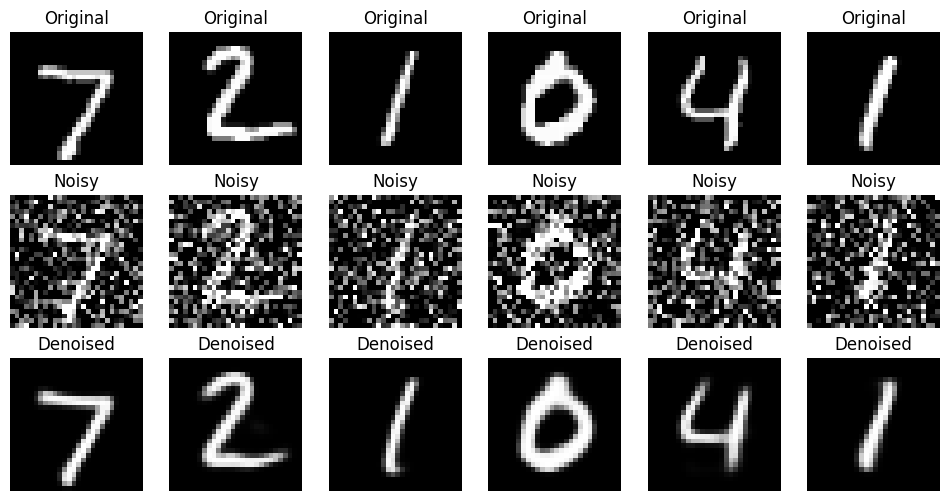

In [13]:

# ----------------------------
# 6. Visualization
# ----------------------------
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    noisy_images = add_noise(images)
    outputs = model(noisy_images)

images = images.cpu()
noisy_images = noisy_images.cpu()
outputs = outputs.cpu()

# Plot: Original vs Noisy vs Reconstructed
n = 6
plt.figure(figsize=(12,6))

for i in range(n):
    # Original
    plt.subplot(3, n, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    plt.subplot(3, n, i+1+n)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Reconstructed
    plt.subplot(3, n, i+1+2*n)
    plt.imshow(outputs[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.show()

# Discussion:

Same thing as before it does it a pretty food job. The thickness of all the number slightly varies but at least the brightness level is consistent than the results with the previous model. The last result had some fading portions like the one seen with 7.

The problem with comparison is that the dataset is "too easy" if there was a mre complex dataset, the improvement/deterioration in performance with regards to model architecture would be more apparent.

# **Implementing VAE!**

In [14]:
# ----------------------------
# VAE Model
# ----------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        # ----------------------------
        # Encoder
        # ----------------------------
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 14 -> 7
            nn.ReLU()
        )

        self.flatten = nn.Flatten()

        # Latent space
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        # ----------------------------
        # Decoder
        # ----------------------------
        self.fc_decode = nn.Linear(latent_dim, 64 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),  # 14 -> 28
            nn.Sigmoid()
        )

    # ----------------------------
    # Reparameterization Trick
    # ----------------------------
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x)
        x = self.flatten(x)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        z = self.reparameterize(mu, logvar)

        x = self.fc_decode(z)
        x = self.decoder(x)

        return x, mu, logvar


model = VAE().to(device)

We're using a different loss function here. The Reconstruction Loss (BCE + KL Loss)

In [15]:
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction loss
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL Divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss

In [16]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        recon, mu, logvar = model(images)
        loss = vae_loss(recon, images, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 20421.3481
Epoch [2/10], Loss: 15244.6018
Epoch [3/10], Loss: 14496.3849
Epoch [4/10], Loss: 14100.6111
Epoch [5/10], Loss: 13872.8344
Epoch [6/10], Loss: 13720.5027
Epoch [7/10], Loss: 13612.9993
Epoch [8/10], Loss: 13526.0724
Epoch [9/10], Loss: 13458.5652
Epoch [10/10], Loss: 13397.0254


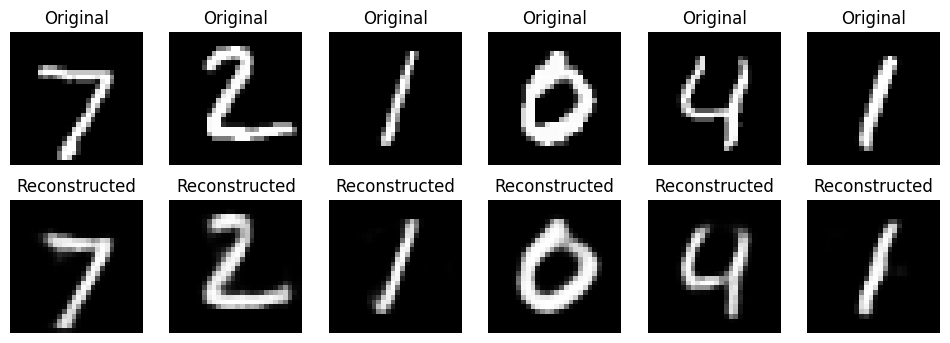

In [17]:
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)

    recon, _, _ = model(images)

images = images.cpu()
recon = recon.cpu()

import matplotlib.pyplot as plt

n = 6
plt.figure(figsize=(12,4))

for i in range(n):
    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i+1+n)
    plt.imshow(recon[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

# Discussion

This is even more blurry than Deep AE and the original AE models that we implemented earlier. One thing to notice during the training process is that the losses were incredibly high. This could be because we are using a new loss function to calculate loss as opposed to just calculating BCELoss.

Generating new images

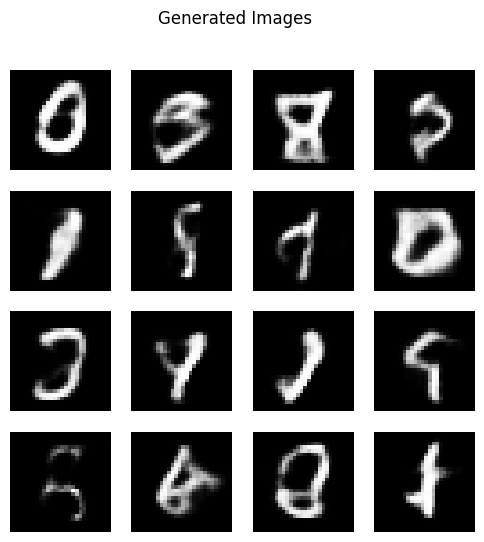

In [18]:
model.eval()

with torch.no_grad():
    z = torch.randn(16, 20).to(device)  # 20 = latent_dim
    samples = model.decoder(model.fc_decode(z))

samples = samples.cpu()

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Generated Images")
plt.show()

# Discussion:
To feed my curiosity, I generated new images with VAE. They look pretty bad. The only recognizable numbers are 0 and 8. The rest could be potential new numbers if someday human beings decide to move from the decimal system to a new one!